<a href="https://colab.research.google.com/github/stephenfrein/vucsc8491/blob/main/Week4_Clustering_and_Association_Rules.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 4: Clustering and Association Rules

This week, we'll cover two "unsupervised" data mining techniques:

1. **Clustering**: finding groups of similar observations when we do not already have labels
2. **Association rules**: finding combinations of features or items that tend to appear together


## Refresher on Supervised vs Unsupervised Learning

**Supervised** learning refers to cases in which we have historical examples labeled with some outcome (e.g., a rainfall amount, whether a loan defaulted, etc.) and we're trying to find the relationship between a set of predictor variables and that historical outcome. We'll embody that relationship in some kind of model, and use the model to both *understand* why things happened and *predict* what is likely to happen in the future.

We call the learning *supervised* because the construction of our model is governed by training data in which we have access to the real outcome (what actually happened, sometimes called the "ground truth"). The model-building process adjusts the structure of the model to align with the actual outcomes recorded in our training data.

**Unsupervised** learning refers to cases in which our training data isn't labeled with some kind of outcome that we're trying to predict. Rather, our goal is to look for patterns and structure in the data. This generally results in us creating new labels or designations that weren't in the data originally. Unsupervised learning can be said to create new data.

## Clustering

Clustering allows to take a set of examples and create groupings based on similarity. We usually can't reason about many individual examples effectively, so it helps to group them into collections that we can manage more readily.

Examples of what we might cluster:

* customers (to create personas for marketing and establish sales regions)
* students (who is engaged? successful? needing help?)
* activity (what kinds of work are we processing? what is anomalous?)


## First Steps - the Iris Data Set

We'll use the famous iris data set to demonstrate clustering. This is a toy example, because each row already has an iris species identified, but we're going to pretend that isn't there, build clusters on the basis of the other attributes, and then see how our clusters compare to the actual species variants.

In [ ]:
import matplotlib.pyplot as plt
from sklearn import datasets # iris already baked into scikit-learn
# we'll use a clustering algorithm called k-means that we'll explain soon
from sklearn.cluster import KMeans

# load iris data as data frame
iris = datasets.load_iris(as_frame=True)
# remember we commonly use "X" as a collective representation of predictor variables
X = iris.data
# target is common term for ouctome variable to be predicted
species = iris.target

X.head()

In [ ]:
import plotly.express as px
 # iris already baked into scikit-learn
from sklearn import datasets
# we'll need to scale our data because of a distance calculation
from sklearn.preprocessing import StandardScaler
# we'll use a clustering algorithm called k-means that we'll explain soon
from sklearn.cluster import KMeans

# load iris data as data frame
iris = datasets.load_iris(as_frame=True)
iris_df = iris.frame

display(iris_df.head())

# convert the species numbers (0, 1, 2) into actual names for graph legend
iris_df['species'] = iris_df['target'].map({0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'})
# get rid of target column
iris_df.drop(columns='target', inplace=True)

# see what 5 random rows look like
# without random_state argument, it's different each time
display(iris_df.sample(n=5))


In [ ]:
# define params for k-means clustering - we'll explain this better shortly
# for now, know we specify number of clusters (3) in advance
kmeans = KMeans(n_clusters=3, random_state=123, n_init='auto')

# specific columns to use for clustering
feature_cols = [
    'sepal length (cm)',
    'sepal width (cm)',
    'petal length (cm)',
    'petal width (cm)'
]

# scale the features and save in new 2D numpy array (like dataframe)
# we scale because larger numbers will overwhelm distance calculation
scaler = StandardScaler()
scaled_features = scaler.fit_transform(iris_df[feature_cols])

# show difference between original and scaled values
print('Original Feature Values')
display(iris_df.head())
print('--------------------------------')
print('Scaled Feature Values')
display(scaled_features[:5]) # first 5 rows of 2D numpy array
print('--------------------------------')

# run k-means clustering using only the scaled feature columns
# we convert the numeric clusters to strings because this will plot better
iris_df['cluster'] = kmeans.fit_predict(scaled_features).astype(str)

# show 5 random rows to demonstrate species added
print('\nWith Species Added to Original Data...')
display(iris_df.sample(n=5))

# create 3d plot
fig = px.scatter_3d(
    iris_df,
    x='petal length (cm)',
    y='petal width (cm)',
    z='sepal length (cm)',
    color='cluster', # the cluster that came from predictor similarity
    color_discrete_map={'0': 'yellow', '1': 'green', '2': 'blue'}, # colors
    symbol='species',   # the actual flower species
    symbol_sequence=['diamond-open', 'square', 'circle'], # make shapes very different
    title="3D Clustering: Colors = Clusters | Shapes = Species",
)

# make the markers larger with a border so they are easy to see
fig.update_traces(marker=dict(size=6, line=dict(width=1, color='black')))
# no legend
fig.update_layout(showlegend=False)


## Exercise 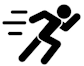

Describe how the clusters relate to the actual species labels.

## K-Means Clustering

K-means clustering is a simple but powerful clustering algorithm. It requires you to specify the number of clusters you want to create upfront. Sometimes, you might know that number in advance - for example, you might decide that a retail store chain is going to be split into 4 separate regions for management purposes.

You may not always know the number of clusters you want in advance. I'll give you some guidance on that scenario shortly.

**How K-Means Works**

In a nutshell:

* randomly place *k* "centroids" (cluster centers) in your data
* assign each data point to its nearest centroid (cluster)
* after the points are assigned to a cluster, find the middle of that cluster and move the corresponding centroid to it
* moving the centroids may change the membership of the clusters - recalculate the cluster membership
* stop when the algorithm converges (no more movement because things are stable)


2D visualization of k-means below using k=3 (3 clusters):

kmeans_4row_2col_v3.svg

## How Many Clusters Should I Have?

You may not always know in advance how many clusters you should have, but there are methods you can use to figure this out.

### WCSS (Within-Cluster Sum of Squares)

WCSS is a method you can use to calculate how tightly clustered your data is. Calculating WCSS for a number of different possible cluster values (say, 2-10) helps you to determine the point at which adding additional clusters brings too little value (reduction in WCSS) to be worth it.

To calculate WCSS, we:

1.   Calculate the distance between each point and its associated centroid
2.   Square each distance (all positive values, farther penalized more)
3.   Sum all the squared distances (that number is your WCSS

If you plot the WCSS for each potential number of clusters, you'll likely find an "inflection point" (a place where the slope changes) that shows you the point beyond which adding more clusters results in minimal WCSS reduction.

Just to confuse you, WCSS is also called **inertia**  - the two terms mean the same when we are working with k-means.


### Calculating WCSS and Ideal # of Clusters Step-by-Step

Let's manually determine the optimal number of clusters using k-means clustering and WCSS. This will be a very simple example with a 1D data set, but it will show you the mechanics we use for more complex scenarios.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# start with our data
# how many clusters do you think you see in it?
data_points = [1, 3, 4, 11, 13, 14]

# how many clusters (k) might we use?
potential_k_values = [1, 2, 3, 4]
# array to store WCSS for plotting
wcss_values = []

# seed random number generator
# I cheated a bit here to get an outcome I liked :)
# this is because data set is unusually small
np.random.seed(101)

for k in potential_k_values:
    print('Testing k = ' + str(k))
    # create k random numbers within the range of data points
    centroids = [np.random.uniform(min(data_points), max(data_points)) for _ in range(k)]
    print('Initial Centroids: ' + str(centroids))

    converged = False # are we done refining clusters yet?
    iterations = 0
    max_iterations = 100 # safety net to prevent infinite loops

    while not converged and iterations < max_iterations:
        print('---Iteration ' + str(iterations) + '---')
        # create an empty dictionary to hold our clusters
        clusters = {i: [] for i in range(k)}

        for point in data_points:
            print('For point: ' + str(point))
            # calculate distance from the point to every centroid
            distances = [abs(point - c) for c in centroids]
            print('Distances to centroids: ' + str(distances))
            # now print out each distance individually
            # for c in centroids:
            #  print('Distance between point and centroid at ' + str(c) + ' is ' + str(abs(point - c)))
            # find the index of the minimum distance
            closest_centroid_index = distances.index(min(distances))
            print('Closest centroid is at index ' + str(closest_centroid_index))
            # assign the point to that cluster (centroid)
            clusters[closest_centroid_index].append(point)

        print('Current cluster assignments: ')
        print(clusters)

        # now recalculate centroids based on the new assignments
        new_centroids = []
        for i in range(k):
            if clusters[i]:
                # the new centroid is the average of the points in the cluster
                cluster_average = sum(clusters[i]) / len(clusters[i])
                new_centroids.append(cluster_average)
                print('For cluster ' + str(i) + ' the new centroid is ' + str(cluster_average))
            else:
                # if a cluster ended up empty, keep the centroid where it was
                new_centroids.append(centroids[i])

        # If the centroids haven't moved, algorithm has finished (converged)
        if centroids == new_centroids:
            converged = True
            print('No movement - the algorithm has converged')
        else:
            print('Centroids have moved - need another iteration')
            centroids = new_centroids
            iterations += 1

        print('---End Iteration---')

    # calculate the Within-Cluster Sum of Squares (WCSS)
    wcss = 0
    for i in range(k):
        print('For cluster ' + str(i) + ': ')
        for point in clusters[i]:
            print('The squared distance between point ' + str(point) + ' and centroid ' + str(centroids[i]) + ' is ' + str((point - centroids[i]) ** 2))
            wcss += (point - centroids[i]) ** 2
    print('This sums up to a WCSS of ' + str(wcss))
    wcss_values.append(wcss) # save for the plot

    # output the results for this k
    print(f"--- Testing k = {k} ---")
    print(f"Final Centroids: {[round(c, 2) for c in centroids]}")
    print(f"Final Clusters: {clusters}")
    print(f"WCSS: {round(wcss, 4)}\n")

# plot the WCSS values
plt.figure(figsize=(8, 5))
plt.plot(potential_k_values, wcss_values, marker='o', linestyle='-', color='b', markersize=8)
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(potential_k_values) # Force x-axis to show only integers (1, 2, 3)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()






**??? Where is the "elbow" (point where slope changes dramatically) in the WCSS curve above? ???**

## Exercise 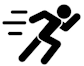

What is the WCSS (inertia) of this 1D data set? [1, 3, 5, 7, 9]

## Real Scenario: Understanding Private Cloud Usage

You work for a large enterprise that maintains its own private cloud of virtual machines. You want to understand how the cloud is being used by internal development teams. There are thousands of machines, so you need some kind of abstraction to help you think about the usage.

You have 30 days of usage data available. You decide to use k-means clustering to see if you can identify classes of virtual machine usage.

In [ ]:
# we'll use a library called kneed to help us determine the # of clusters
!pip install kneed

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
# knee and elbow are mirror concepts (convex vs concave)
from kneed import KneeLocator

# pd.set_option("display.float_format", "{:.2f}".format)

vms_raw_df = pd.read_csv('https://raw.githubusercontent.com/stephenfrein/vucsc8491/refs/heads/main/vm_telemetry.csv')

print('First 5 rows')
display(vms_raw_df.head())

print('\n5 random rows')
display(vms_raw_df.sample(n=5))

In [ ]:
# list of feature columns we will aggregate statistically
features = [
    "Provisioned_vCPU_Count",
    "Provisioned_Memory_GB",
    "Provisioned_Disk_Capacity_GB",
    "Average_Daily_CPU_Utilization_Percentage",
    "Peak_Daily_CPU_Utilization_Percentage",
    "CPU_Ready_Wait_Time_Milliseconds",
    "Average_Daily_Memory_Utilization_Percentage",
    "Active_Memory_In_Gigabytes",
    "Memory_Swap_Rate_KBps",
    "Disk_Read_Operations_Per_Second_IOPS",
    "Disk_Write_Operations_Per_Second_IOPS",
    "Inbound_Network_Traffic_Mbps",
    "Outbound_Network_Traffic_Mbps",
    "Concurrent_Network_Connections_Count",
]

# get average value of each feature for each VM so we can cluster/plot specific VMs
vms = vms_raw_df.groupby("Virtual_Machine_Identifier")[features].mean().reset_index()
display(vms.sample(n=5))


# scale the data in preparation for k-means
scaled_features = StandardScaler().fit_transform(vms[features])

# remember, inertia is the same as WCSS
inertias = []
# this will check k values between 2 and 10
for k in range(2, 11):
    # find the WCSS (inertia) values for each number of clusters
    inertias.append(KMeans(n_clusters=k, random_state=123, n_init='auto').fit(scaled_features).inertia_)

# what value of K is best? KneeLocator will find best inflection point in WCSS curve
# for elbow curve like this, curve always be concave and decreasing
# yes, "knee" is correct here for an elbow plot - it's a quirk of the library
optimal_k = KneeLocator(range(2, 11), inertias, curve="convex", direction="decreasing").knee
print(f"Optimal k: {optimal_k}")

fig, ax = plt.subplots(figsize=(8, 4))
# plot will be dots connected by lines
ax.plot(range(2, 11), inertias, "o-", color="blue", linewidth=2)
# show vertical line where opitmal k is
ax.axvline(optimal_k, color="red", linestyle="--", linewidth=1.5, label=f"Elbow k={optimal_k}")
ax.set_xlabel("k");
ax.set_ylabel("WCSS (Inertia)")
ax.set_title("Elbow Plot — VM telemetry");
ax.legend()
plt.tight_layout();
plt.show()


In [ ]:
# how did the optimal cluster value (elbow) get determined?
# here is what's happening with the "kneedle" algorithm
# don't worry about all the code - absorb the concepts

import matplotlib.pyplot as plt
import numpy as np

k_values_np = np.array(range(2, 11))
inertias_np = np.array(inertias)

# normalize both k-values inertias (WCSS) to a [0, 1] scale
k_norm = (k_values_np - k_values_np.min()) / (k_values_np.max() - k_values_np.min())
inertias_norm = (inertias_np - inertias_np.min()) / (inertias_np.max() - inertias_np.min())

# get the index of the optimal_k to use for highlighting later
optimal_index = np.where(k_values == optimal_k)[0][0]

fig, ax = plt.subplots(figsize=(7, 7)) # need a square plot to show correctly

# plot the normalized curve
ax.plot(k_norm, inertias_norm, "o-", color="blue", linewidth=2, label="Normalized WCSS")

# calculate and plot the secant line in the new normalized space
# this line connects first point to last
x1, y1 = k_norm[0], inertias_norm[0]
xn, yn = k_norm[-1], inertias_norm[-1]
ax.plot([x1, xn], [y1, yn], "k--", alpha=0.6, label="Secant Line")

# figure out slope and intercept of secant line
m = (yn - y1) / (xn - x1)
c = y1 - m * x1

# calculate perpendicular (from secant line) drops using the normalized coordinates
for i in range(len(k_norm)):
    x0, y0 = k_norm[i], inertias_norm[i]
    xp = (x0 + m * y0 - m * c) / (1 + m**2)
    yp = m * xp + c

    label = "Perpendicular Dist" if i == 0 else None

    if i == optimal_index:
        ax.plot([x0, xp], [y0, yp], color="green", linestyle="-", linewidth=2.5,
                zorder=5, label=f"Max Dist (k={optimal_k})")
    else:
        ax.plot([x0, xp], [y0, yp], color="gray", linestyle=":", linewidth=1.5, label=label)

# 4. add vertical line at the optimal k
optimal_k_norm = k_norm[optimal_index]
ax.axvline(optimal_k_norm, color="red", linestyle="--", linewidth=1.5, label=f"Elbow k={optimal_k}")

# force the visual aspect ratio to be exactly 1:1
ax.set_aspect('equal', adjustable='box')

ax.set_xlabel("Normalized k")
ax.set_ylabel("Normalized WCSS")
ax.set_title("Normalized Elbow Plot (True 90° Distances)")
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# add cluster-designating column to VMs
vms["Cluster"] = KMeans(n_clusters=optimal_k, random_state=123, n_init='auto').fit_predict(scaled_features)
display(vms["Cluster"].value_counts().sort_index().rename("VM count"))


# shortened column names for plots
short = {
    "Provisioned_vCPU_Count":                      "vCPUs",
    "Provisioned_Memory_GB":                        "Prov Mem (GB)",
    "Provisioned_Disk_Capacity_GB":                 "Prov Disk (GB)",
    "Average_Daily_CPU_Utilization_Percentage":     "Avg CPU %",
    "Peak_Daily_CPU_Utilization_Percentage":        "Peak CPU %",
    "CPU_Ready_Wait_Time_Milliseconds":             "CPU Wait (ms)",
    "Average_Daily_Memory_Utilization_Percentage":  "Avg Mem %",
    "Active_Memory_In_Gigabytes":                   "Active Mem (GB)",
    "Memory_Swap_Rate_KBps":                        "Swap (KBps)",
    "Disk_Read_Operations_Per_Second_IOPS":         "Disk Read IOPS",
    "Disk_Write_Operations_Per_Second_IOPS":        "Disk Write IOPS",
    "Inbound_Network_Traffic_Mbps":                 "Net In (Mbps)",
    "Outbound_Network_Traffic_Mbps":                "Net Out (Mbps)",
    "Concurrent_Network_Connections_Count":         "Connections",
}


summary = (
    # get the average values of the features per cluster
    # rename the columns for plotting and transpose (rotate data sideways) for heatmap
    vms.groupby("Cluster")[features].mean().rename(columns=short).T
)
# now that we transposed data and rows are columns, let's name the columns
summary.columns = [f"Cluster {c}" for c in summary.columns]
print(summary.to_string())

In [ ]:
# let's make a heatmap to see where extreme values are

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# we'll normalize the data on a 0-1 scale because the measurements have different scales
# we're normalizing by row here, because each row is a different measurement
# a lambda is basically an anonymous, single use function
# .apply is applying it to all rows (axis=1) of summary
# the 1e-9 is an "epsilon value" (super small number) that avoids division by zero
norm = summary.apply(lambda r: (r - r.min()) / (r.max() - r.min() + 1e-9), axis=1)

# grab the non-normalized values as labels for the heatmap cells
# actual colors will be based on the normalized values
# loop thhrough all rows of summary and capture all values
# format the decimal places depending on how large values are
custom_annotations = np.array([
    [f"{v:,.1f}" if v < 1000 else f"{v:,.0f}" for v in row]
    for row in summary.values
])

# keep graph width flexible depending on # of clusters
fig, ax = plt.subplots(figsize=(max(6, optimal_k * 1.6), 7))

# draw heatmap
sns.heatmap(
    data=norm,                   # the 0-1 scaled data for the colors
    annot=custom_annotations,    # the formatted text to put inside the boxes
    fmt="",                      # format the annotations (labels) as-is
    cmap="Blues",                # color palette - single color family easier to read here
    ax=ax                        # put it on our dynamically sized canvas
)

ax.set_title("Average metric per cluster (color = relative intensity)", fontweight="bold")
plt.tight_layout()
plt.show()

## Exercise 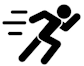

Describe the 6 clusters - what kind of VMs do they each represent? Think about what each cluster does most heavily - the darkest blues.

(Try to form theories first on your own. If you're having a hard time, ask your favorite LLM to help.)

In [ ]:
# graph clusters in 3D scatteplot

import plotly.express as px
import plotly.graph_objects as go

vms_df_3d = vms.copy()
# make cluster a string for plotting
vms_df_3d["Cluster"] = vms_df_3d["Cluster"].astype(str)

X_AX = "Average_Daily_CPU_Utilization_Percentage"
Y_AX = "Average_Daily_Memory_Utilization_Percentage"
Z_AX = "Outbound_Network_Traffic_Mbps"

fig = px.scatter_3d(
    vms_df_3d, x=X_AX, y=Y_AX, z=Z_AX, color="Cluster",
    hover_name="Virtual_Machine_Identifier",
    labels={X_AX: "Avg CPU (%)", Y_AX: "Avg Mem (%)", Z_AX: "Net Out (Mbps)"},
    title=f"VM clusters (k={optimal_k})",
    #color_discrete_sequence=px.colors.qualitative.Bold,
    opacity=0.75
)
fig.update_traces(marker=dict(size=3))
fig.update_layout(showlegend=False)
fig.update_layout(height=650, margin=dict(l=0, r=0, b=0, t=50))
fig.show()

## Exercise 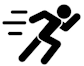

Which clusters have the poorest separation? Can you get all 6 distinct by swapping in different axis variables?

## Try Cluster Separation with PCA

In [ ]:
vms.info()

In [ ]:
from sklearn.decomposition import PCA

# reminder of per-VM data we created above
vms.sample(n=5)

# new copy for PCA work
vms_pca_df = vms.copy()

# save cluster column
cluster_labels = vms_pca_df['Cluster'].astype(str)
# drop cluster column from df
vms_pca_df = vms_pca_df.drop(columns=['Cluster'])

# get numeric features
vms_pca_feature_cols = vms_pca_df.select_dtypes(include='number').columns.tolist()

scaler = StandardScaler()
pca_scaled_features = scaler.fit_transform(vms_pca_df[vms_pca_feature_cols])

# perform PCA with 3 components
pca = PCA(n_components=3, random_state=123)
pca_coords = pca.fit_transform(pca_scaled_features)

# show explained variance
explained = pca.explained_variance_ratio_
print(f"\nExplained variance by component:")
for i, ev in enumerate(explained, 1):
    print(f"  PC{i}: {ev:.1%}")
print(f"  Total: {sum(explained):.1%}")

# put PCA coords back in a dataframe alongside cluster labels
plot_pca_df = pd.DataFrame(
    pca_coords,
    columns=['PC1', 'PC2', 'PC3']
)
plot_pca_df['Cluster'] = cluster_labels

# create scatterplot
fig = px.scatter_3d(
    plot_pca_df,
    x='PC1',
    y='PC2',
    z='PC3',
    color='Cluster',
    title=(
        f"K-Means Clusters in PCA Space<br>"
        f"<sup>PC1={explained[0]:.1%}, PC2={explained[1]:.1%}, "
        f"PC3={explained[2]:.1%} of variance explained</sup>"
    ),
    labels={
        'PC1': f'PC1 ({explained[0]:.1%})',
        'PC2': f'PC2 ({explained[1]:.1%})',
        'PC3': f'PC3 ({explained[2]:.1%})',
    }
)

fig.update_traces(
    marker=dict(
        size=5,
        opacity=0.3,
    )
)

fig.update_layout(
    legend_title_text='Cluster',
    scene=dict(
        xaxis_title=f'PC1 ({explained[0]:.1%})',
        yaxis_title=f'PC2 ({explained[1]:.1%})',
        zaxis_title=f'PC3 ({explained[2]:.1%})',
    )
)

fig.show()

## 10. Hierarchical clustering

Hierarchical clustering builds clusters step by step. It can be visualized with a **dendrogram**, which shows how observations or groups are merged together.

A dendrogram is useful because it lets us see clustering structure at different levels, not just one fixed value of k.

In [ ]:
# Create a linkage matrix for the dendrogram.
# Ward linkage is commonly used with numeric, scaled data.
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(linked, truncate_mode='lastp', p=30, leaf_rotation=90)
plt.title('Hierarchical Clustering Dendrogram: Last 30 Merged Clusters')
plt.xlabel('Cluster or Observation')
plt.ylabel('Distance')
plt.show()

In [ ]:
agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
wine_df['hierarchical_cluster_3'] = agg.fit_predict(X_scaled)

pd.crosstab(wine_df['class'], wine_df['hierarchical_cluster_3'])

In [ ]:
fig = px.scatter(
    cluster_plot_df.assign(hierarchical_cluster_3=wine_df['hierarchical_cluster_3'].astype(str)),
    x='pc1',
    y='pc2',
    color='hierarchical_cluster_3',
    symbol='class',
    title='Hierarchical Clusters Visualized with PCA'
)
fig.show()

## 11. DBSCAN

DBSCAN is a density-based clustering method. Unlike K-Means, it does not require us to choose the number of clusters in advance.

Instead, we choose:

- `eps`: how close points need to be to count as neighbors.
- `min_samples`: how many nearby points are needed to form a dense region.

DBSCAN can also label some points as noise using cluster label `-1`.

In [ ]:
dbscan = DBSCAN(eps=2.2, min_samples=5)
wine_df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

wine_df['dbscan_cluster'].value_counts().sort_index()

In [ ]:
pd.crosstab(wine_df['class'], wine_df['dbscan_cluster'])

In [ ]:
fig = px.scatter(
    cluster_plot_df.assign(dbscan_cluster=wine_df['dbscan_cluster'].astype(str)),
    x='pc1',
    y='pc2',
    color='dbscan_cluster',
    symbol='class',
    title='DBSCAN Clusters Visualized with PCA'
)
fig.show()

### A note about DBSCAN

DBSCAN can work very well when clusters are irregularly shaped and separated by sparse areas. But it is sensitive to `eps` and `min_samples`, especially when the data has many dimensions.

For this dataset, K-Means and hierarchical clustering may be easier to interpret.

# Part 2: Association Rules

Association rules are often used in market basket analysis. A classic example is:

> Customers who buy chips and salsa also often buy soda.

The basic idea is to find combinations of items that appear together more often than expected.

Our wine dataset is not a shopping basket dataset, but we can create basket-like records by converting chemical measurements into labels such as:

- `high_alcohol`
- `low_color_intensity`
- `medium_magnesium`

Each wine becomes a basket of descriptive chemical properties.

## 12. Important association rule terms

For a rule like:

> `high_alcohol` → `high_proline`

The left side is called the **antecedent** and the right side is called the **consequent**.

Three important metrics are:

- **Support**: how often the itemset appears in all records.
- **Confidence**: when the antecedent appears, how often the consequent also appears.
- **Lift**: how much more common the consequent is when the antecedent appears compared with overall.

A lift greater than 1 suggests a positive association.

## 13. Convert numeric columns into basket-style items

We will bin each numeric column into low, medium, and high categories using quantiles.

This is not the only way to create transactions, but it is a useful teaching example because it turns ordinary numeric data into association-rule-ready data.

In [ ]:
# Make a new dataframe of binned feature labels.
binned_df = pd.DataFrame(index=wine_df.index)

for col in X.columns:
    binned_df[col] = pd.qcut(
        wine_df[col],
        q=3,
        labels=[f'low_{col}', f'medium_{col}', f'high_{col}'],
        duplicates='drop'
    )

binned_df.head()

In [ ]:
# Each row can now be thought of as a basket of descriptive items.
transactions = binned_df.apply(lambda row: list(row.dropna()), axis=1)
transactions.head()

## 14. One-hot encode the transactions

The Apriori algorithm expects a dataframe where:

- Each row is a transaction.
- Each column is an item.
- Each value is True or False.

In [ ]:
# Convert the transaction lists to a one-hot encoded dataframe.
te = TransactionEncoder()
one_hot_array = te.fit(transactions).transform(transactions)
one_hot = pd.DataFrame(one_hot_array, columns=te.columns_)

one_hot.head()

In [ ]:
one_hot.shape

## 15. Find frequent itemsets with Apriori

A frequent itemset is a group of items that appears together in at least some minimum percentage of records.

Here we will start with `min_support=0.20`, which means the itemset must appear in at least 20% of the wines.

In [ ]:
frequent_itemsets = apriori(
    one_hot,
    min_support=0.20,
    use_colnames=True
)

frequent_itemsets = frequent_itemsets.sort_values('support', ascending=False)
frequent_itemsets.head(20)

### Look for larger itemsets

Single-item itemsets are not very interesting. We usually care more about combinations of two or more items.

In [ ]:
frequent_itemsets['itemset_size'] = frequent_itemsets['itemsets'].apply(len)

frequent_itemsets[frequent_itemsets['itemset_size'] >= 2].head(20)

## 16. Generate association rules

Now we can turn frequent itemsets into rules. We will begin by keeping rules with confidence of at least 70%.

In [ ]:
rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=0.70
)

rules = rules.sort_values(['lift', 'confidence'], ascending=False)
rules.head(20)

The output contains a lot of columns. For interpretation, it helps to keep only the most important ones.

In [ ]:
rules_simple = rules[[
    'antecedents',
    'consequents',
    'support',
    'confidence',
    'lift'
]].copy()

rules_simple.head(15)

In [ ]:
# Convert frozensets to cleaner strings for display.
def itemset_to_string(itemset):
    return ', '.join(sorted(list(itemset)))

rules_simple['antecedents'] = rules_simple['antecedents'].apply(itemset_to_string)
rules_simple['consequents'] = rules_simple['consequents'].apply(itemset_to_string)

rules_simple.head(15)

## 17. Visualize association rules

A scatterplot can help us compare rules by support, confidence, and lift.

In [ ]:
fig = px.scatter(
    rules,
    x='support',
    y='confidence',
    size='lift',
    color='lift',
    hover_data=['antecedents', 'consequents'],
    title='Association Rules: Support, Confidence, and Lift'
)
fig.show()

## 18. Interpret a rule in plain English

Let's take one of the strongest rules and write it as a sentence.

In [ ]:
if len(rules_simple) > 0:
    best_rule = rules_simple.iloc[0]
    print('Rule:')
    print(f"If a wine has: {best_rule['antecedents']}")
    print(f"Then it also tends to have: {best_rule['consequents']}")
    print()
    print(f"Support: {best_rule['support']:.2f}")
    print(f"Confidence: {best_rule['confidence']:.2f}")
    print(f"Lift: {best_rule['lift']:.2f}")
else:
    print('No rules found. Try lowering min_support or min_threshold.')

## 19. Association rules by known class

The wine classes are not needed for association rules, but adding class-based items can help us see which chemical patterns are associated with known wine types.

This turns the class label into an item like `class_1`, `class_2`, or `class_3`.

In [ ]:
transactions_with_class = binned_with_class.apply(lambda row: list(row.dropna()), axis=1)

te_class = TransactionEncoder()
one_hot_with_class_array = te_class.fit(transactions_with_class).transform(transactions_with_class)
one_hot_with_class = pd.DataFrame(one_hot_with_class_array, columns=te_class.columns_)

one_hot_with_class.head()

In [ ]:
frequent_itemsets_class = apriori(
    one_hot_with_class,
    min_support=0.15,
    use_colnames=True
)

frequent_itemsets_class['itemset_size'] = frequent_itemsets_class['itemsets'].apply(len)

rules_class = association_rules(
    frequent_itemsets_class,
    metric='confidence',
    min_threshold=0.70
)

rules_class_simple = rules_class[[
    'antecedents',
    'consequents',
    'support',
    'confidence',
    'lift'
]].copy()

rules_class_simple['antecedents'] = rules_class_simple['antecedents'].apply(itemset_to_string)
rules_class_simple['consequents'] = rules_class_simple['consequents'].apply(itemset_to_string)

# Show rules where the consequent is a wine class.
class_rules = rules_class_simple[
    rules_class_simple['consequents'].str.contains('class_')
].sort_values(['lift', 'confidence'], ascending=False)

class_rules.head(20)

## 20. Mini-exercise: Try different settings

Try changing these values and see what happens:

- For clustering:
  - `n_clusters` in K-Means
  - `eps` in DBSCAN
  - `min_samples` in DBSCAN

- For association rules:
  - `min_support` in `apriori()`
  - `min_threshold` in `association_rules()`

Questions to answer:

1. What value of k seems best for K-Means? Why?
2. Which clustering method seemed easiest to interpret?
3. Did the clusters line up with the known wine classes?
4. What was one association rule that seemed meaningful?
5. What is the difference between a high-confidence rule and a high-lift rule?

# Optional Extension: Applying these ideas to IPEDS

The same approach can be applied to the IPEDS data from the course repository.

Possible clustering questions:

- Can we cluster colleges based on size, admissions, tuition, graduation rate, and financial aid?
- Do public/private schools naturally separate into different clusters?
- Does Villanova cluster with schools we would expect?

Possible association rule questions:

- Are high graduation rates associated with high admissions selectivity?
- Are high tuition and high financial aid often found together?
- Are certain institutional characteristics associated with Carnegie classification or control type?

This would make a good homework or project extension because students need to make their own choices about feature selection and interpretation.

# Summary

In this notebook, we used unsupervised learning methods to find patterns without training on a target variable.

For clustering, we:

- Scaled the numeric features.
- Fit K-Means, hierarchical clustering, and DBSCAN.
- Compared possible values of k using inertia and silhouette score.
- Visualized clusters using PCA.
- Interpreted clusters by looking at feature averages.

For association rules, we:

- Converted numeric wine measurements into low/medium/high items.
- Used Apriori to find frequent itemsets.
- Generated rules using confidence.
- Interpreted rules using support, confidence, and lift.

The main lesson is that unsupervised learning does not automatically tell us the meaning of a pattern. It gives us a structure to investigate. The human analyst still has to decide whether the pattern is useful, surprising, or actionable.